## Working with EEG data 
We learned how to load basic information about CML experiments and experimental events. Next, we're going to load EEG/iEEG data that correspond to those events.

### What is EEG? 
Before we get into the weeds, let's briefly review exactly what EEG is, how we collect it, and what we can learn from it. Much of this material is sourced from this paper by Pesaran, et al. (2018): https://www.nature.com/articles/s41593-018-0171-8

The fundamental signal detected by any electrical brain sensor is the **field potential**, or the change in extracellular voltage induced by aggregated electrical currents across a population of neurons. In other words, as neurons communicate with one another, ions flow across channels at synapses (and along the axon during action potentials). These ionic flows set up a difference in the electrical potential between two areas of brain tissue, which is detected by a sensor placed within the brain (iEEG/sEEG), on the cortical surface (ECoG), or on the scalp (EEG). 

Typically, we refer to the **local field potential (LFP)** when we're talking about field potentials detected by electrodes inserted directly into brain tissue -- such as stereo-EEG depth electrodes -- and **electrocorticography (ECoG)** when we're talking about field potentials detected by electrodes that sit on the surface of the brain. Often, you'll find both of these types of signals in one patient. 

<br>
<center>
<img src="https://media.springernature.com/m685/springer-static/image/art%3A10.1038%2Fs41593-018-0171-8/MediaObjects/41593_2018_171_Fig1_HTML.jpg" width=400>
</center>

The exact neural source of a field potential is not always clear, and it can depend on the placement of an electrode relative to the underlying geometry of neurons and their component parts. For example, a scalp EEG electrode is detecting a field potential generated by the activity of millions of cells in a broad area of the brain near the electrode -- and filtered through the skull and scalp -- while a depth electrode placed in the hippocampus directly records the activity from only a few thousand cells.

The synchronized activity of many cells near an electrode gives rise to an **oscillation**, or a rhythmic fluctuation of the field potential at a particular frequency. The presence of an oscillation is thought to indicate the coordinated neural activity of (or inputs to) a given region, but their origins are multifactorial. Oscillations themselves can affect the firing of neurons, making them an important phenomenon to study in the context of cognition and behavior. We'll talk more about oscillations later. 

### Invasive Monitoring for Epilepsy Surgery (Optional)

<center>
<img src="https://github.com/esolomon/PythonBootcamp2019/blob/master/figures/iEEG_methods-01.jpg?raw=true" width=700>
</center>

Why do we collect EEG? Noninvasive methods, such as scalp EEG and MEG, are safe to use on healthy people. But invasive recordings such as stereo-EEG and ECoG must be justified with a clinical need. Patients with medication-resistant epilepsy come to the hospital for surgical treatment of their epilepsy, in which epileptogenic brain tissue is ablated or removed. But in order to precisely localize this tissue, patients undergo monitoring during which EEG signals are recorded intracranially for several days or weeks, until sufficient seizure events are documented. 

* **(A)** shows a craniotomy, during which a part of the skull is removed so that a grid or strip electrode can be placed on the cortical surface. This method was more common several years ago, and comprises the bulk of early RAM and pre-RAM datasets. 
* **(B)** is a CT-MRI fusion depecting a depth electrode placed in the MTL. So-called "stereo-EEG" depth electrodes are far less invasive, since even a tiny hole in the skull is sufficient to slip one of these wires through. Nowadays, many patients are exclusively stereo-EEG. 

### Load the data

In [ ]:
import numpy as np
import pandas as pd
import mne
from ptsa.data.timeseries import TimeSeries
np.set_printoptions(edgeitems=2, threshold=10)
import sys
sys.path.insert(0, 'dependencies/bidsreader')
from bidsreader import CMLBIDSReader as BIDSReader
from bidsreader import (
    filter_events_df_by_trial_types,
    filter_raw_events_by_trial_types,
    filter_epochs_by_trial_types,
    filter_by_trial_types,
    mne_epochs_to_ptsa,
    mne_raw_to_ptsa,
)

In [2]:
# set root
root = "/data/LTP_BIDS/FR1"

# Specify which subject and experiment we want
sub = 'R1111M'
task = 'FR1'
ses = 0

# load ieeg version of events file
reader = BIDSReader(root=root, subject=sub, task=task, session=ses)
evs = reader.load_events(event_type="ieeg")
word_evs = evs[evs['trial_type']=='WORD']
word_evs[:5]

,onset,duration,sample,trial_type,response_time,stim_file,item_name,serialpos,list,test,answer,experiment,session,subject
27,154.635,1.6,100520,WORD,NaN,wordpools/wordpool_EN.txt,BEAR,1,1,"[0, 0, 0]",NaN,FR1,0,R1111M
28,157.252,1.6,101829,WORD,NaN,wordpools/wordpool_EN.txt,WING,2,1,"[0, 0, 0]",NaN,FR1,0,R1111M
29,159.820,1.6,103113,WORD,NaN,wordpools/wordpool_EN.txt,DOOR,3,1,"[0, 0, 0]",NaN,FR1,0,R1111M
30,162.253,1.6,104329,WORD,NaN,wordpools/wordpool_EN.txt,PLANT,4,1,"[0, 0, 0]",NaN,FR1,0,R1111M
31,164.871,1.6,105638,WORD,NaN,wordpools/wordpool_EN.txt,ROOT,5,1,"[0, 0, 0]",NaN,FR1,0,R1111M


#### Pairs vs. Contacts
In EEG research, “bipolar" and "monopolar" refer to two different ways of defining recording sites and their relationships. A contact is a single electrode point on the brain’s surface or within brain tissue that measures voltage relative to a common reference. In contrast, a pair (often called a bipolar pair) represents the voltage difference between two neighboring contacts. For the most part, you'll be using pairs in the workshop, but if you are unsure which data set you want to use ask a senior lab member. 

Working with contacts is a bit more complicated because it requires that you reference the EEG data yourself. 

#### Load subject electrodes
The BIDS structure separates the electrode data into 3 files which are loaded through the "load_electrodes" function, which returns the location and implant descriptions of each monopolar electrodes, and through the "load_channels" function which returns the unit, sample rate, and cutoffs information for the monopolar or bipolar recordings. 

The location data found in "load_electrodes" is dependent on the coordinate system of the iEEG. Such systems include the MNI152NLin6ASym and Talairach systems. The BIDSReader object automatically infers the cooridnate system.

In [3]:
reader.space

'MNI152NLin6ASym'

## Key Regions 

**All of the bullets points below are columns within the electrodes dataframe!!**

Some key attributes you may need in your analyses include: 
* name: The clinical label for each electrode, as determined in the hospital
* x/y/z: Coordinates in the default space. If the participant was original implanted using the MNI system, then these coordinates refer to MNI. Similarly, if implanted in the Talairach system, then these cooridnates refer to the Talairach coordinates.
* tal.x/y/z or mni.x/y/z: The convereted coordinates fo the non-default space.
* ind.region: The anatomical region using the Desikan-Killiany atlas. 

We use MNI or "ind" coordinates for most analyses in the assignments (available for more subjects).
The x axis points to the right, the y axis to the front, and the z axis up, with the origin (0,0,0) being at the Anterior Commissure (located anatomically between hemispheres at the centre of the brain).
Most electrodes contain the name of the hemisphere and region under a few of the \_.region columns, but a few region labels are missing and can be skipped over.

* For a full description of fields in 'bipolar' or 'monopolar|' structures, see: https://github.com/pennmem/neurorad_pipeline/blob/master/RELEASE_NOTES.md
* For more information on brain coordinate systems, see: http://www.fieldtriptoolbox.org/faq/how_are_the_different_head_and_mri_coordinate_systems_defined/

In [4]:
elec_df = reader.load_electrodes()
elec_df[:5]

,name,x,y,z,size,group,hemisphere,type,tal.x,tal.y,tal.z,wb.region,ind.region,stein.region
0,LPOG1,-67.9554,-20.4363,-26.318920,-999,LPOG,L,grid,-66.7592,-20.3747,-21.06940,NaN,middletemporal,NaN
1,LPOG2,-71.3723,-19.8873,-17.033223,-999,LPOG,L,grid,-68.5270,-19.3056,-13.11050,NaN,middletemporal,NaN
2,LPOG3,-69.4694,-16.8739,-5.837007,-999,LPOG,L,grid,-67.0028,-17.9946,-3.26183,NaN,middletemporal,NaN
3,LPOG4,-68.4177,-13.6191,6.599195,-999,LPOG,L,grid,-62.8222,-17.4965,6.35027,NaN,superiortemporal,NaN
4,LPOG5,-68.5695,-14.2880,16.220750,-999,LPOG,L,grid,-60.2654,-16.0975,16.38480,NaN,postcentral,NaN


In [5]:
mono_df = reader.load_channels(acquisition="monopolar")
mono_df[:5]

,name,type,units,low_cutoff,high_cutoff,group,sampling_frequency,description,notch
0,LPOG1,ECOG,V,NaN,NaN,LPOG,500,grid,NaN
1,LPOG2,ECOG,V,NaN,NaN,LPOG,500,grid,NaN
2,LPOG3,ECOG,V,NaN,NaN,LPOG,500,grid,NaN
3,LPOG4,ECOG,V,NaN,NaN,LPOG,500,grid,NaN
4,LPOG5,ECOG,V,NaN,NaN,LPOG,500,grid,NaN


In [6]:
bi_df = reader.load_channels(acquisition="bipolar")
bi_df[:5]

,name,type,units,low_cutoff,high_cutoff,reference,group,sampling_frequency,description,notch
0,LPOG1-LPOG9,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN
1,LPOG1-LPOG2,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN
2,LPOG2-LPOG10,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN
3,LPOG2-LPOG3,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN
4,LPOG3-LPOG4,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN


In [7]:
# Here is some example code which can be useful in locating specific regions. 
# Note how the ind.region column is being used to filter for certain electrodes. 
latoccipital = elec_df[(elec_df['ind.region'].str.contains("lateral"))
                        & (elec_df['ind.region'].str.contains("occipital"))]
#lo_electrode = latoccipital.iloc[int(len(latoccipital)/2)]
lo_electrode = latoccipital.iloc[0]

**Exercise (Optional): Plot the distributions of 'ind' x, y, and z values for all of R1111Ms electrodes.**

### Creating combined channel dataframes
BIDSReader also contains the "load_combined_channels" function which merges the channels and electrode dfs so you have access to the location and signal data in the same dataframe.

In [8]:
combined_mono_df = reader.load_combined_channels(acquisition="monopolar")
combined_mono_df[:5]

,name,type,units,low_cutoff,high_cutoff,group,sampling_frequency,description,notch,x,...,size,group_elec,hemisphere,type_elec,tal.x,tal.y,tal.z,wb.region,ind.region,stein.region
0,LPOG1,ECOG,V,NaN,NaN,LPOG,500,grid,NaN,-67.9554,...,-999,LPOG,L,grid,-66.7592,-20.3747,-21.06940,NaN,middletemporal,NaN
1,LPOG2,ECOG,V,NaN,NaN,LPOG,500,grid,NaN,-71.3723,...,-999,LPOG,L,grid,-68.5270,-19.3056,-13.11050,NaN,middletemporal,NaN
2,LPOG3,ECOG,V,NaN,NaN,LPOG,500,grid,NaN,-69.4694,...,-999,LPOG,L,grid,-67.0028,-17.9946,-3.26183,NaN,middletemporal,NaN
3,LPOG4,ECOG,V,NaN,NaN,LPOG,500,grid,NaN,-68.4177,...,-999,LPOG,L,grid,-62.8222,-17.4965,6.35027,NaN,superiortemporal,NaN
4,LPOG5,ECOG,V,NaN,NaN,LPOG,500,grid,NaN,-68.5695,...,-999,LPOG,L,grid,-60.2654,-16.0975,16.38480,NaN,postcentral,NaN


For bipolar channels, we can calculate the location of the bipolar pairs by calculating the midpoint between each monopolar electrode in the pair.

In [9]:
combined_bi_df = reader.load_combined_channels(acquisition="bipolar")
combined_bi_df[:5]

,name,type,units,low_cutoff,high_cutoff,reference,group,sampling_frequency,description,notch,...,tal.z_ch2,wb.region_pair,ind.region_pair,stein.region_pair,x_mid,y_mid,z_mid,tal.x_mid,tal.y_mid,tal.z_mid
0,LPOG1-LPOG9,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN,...,-20.14920,NaN,middletemporal,NaN,-66.68055,-24.66905,-26.717305,-66.60470,-25.48000,-20.609300
1,LPOG1-LPOG2,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN,...,-13.11050,NaN,middletemporal,NaN,-69.66385,-20.16180,-21.676071,-67.64310,-19.84015,-17.089950
2,LPOG2-LPOG10,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN,...,-10.86980,NaN,middletemporal,NaN,-70.96495,-24.68495,-16.724423,-68.34015,-24.39265,-11.990150
3,LPOG2-LPOG3,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN,...,-3.26183,NaN,middletemporal,NaN,-70.42085,-18.38060,-11.435115,-67.76490,-18.65010,-8.186165
4,LPOG3-LPOG4,ECOG,V,NaN,NaN,bipolar,LPOG,500,grid,NaN,...,6.35027,NaN,NaN,NaN,-68.94355,-15.24650,0.381094,-64.91250,-17.74555,1.544220


## Loading iEEG/EEG Data

There are multiple ways to load EEG data using the BIDSReader package. The **'load_raw'** function returns an mne.io.BaseRaw object which contains the raw EEG data from the EDF file. You will rarely need to load raw data.

For most analyses, use the **'load_epochs'** function to return an mne.Epochs object.

**'load_epochs'** inputs:
* tmin (float: beginning of epoch window in seconds)
* tmax (float: end of epoch window in seconds)
* trial_types (Optional[Iterable[str]]: trial_types to filter epochs)
* baseline (Optional[Tuple[float | None, float | None]]: range of window in seconds to baseline epoch against, defaults to None which prevents automatic baselining)
* acquisition (Optional[str]: iEEG acquisition) ("bipolar" or "monopolar")
* event_repeated (str: determines how mne.Epochs handles events that occur on the same EEG sample, defaults to "merge" which creates a new event id combining the two events) ("merge", "drop", "error")
* channels (Optional[Iterable[str]]: list of channels labels to select electrodes to keep)
* preload (bool: whether mne.Epochs loads the EEG data into memory, defaults to False)

_Disclaimers:_
* Note that events and electrodes dataframes must be passed as slices, not individual rows. So index them like 'pairs[0:1]' or 'pairs.loc[0:1]' for the first electrode pair, not 'pairs.loc[0]'. Same goes for events!
* **Optional** -- Unrereferenced data is **not available** for subjects collected on the RAM ENS system (marked as system 3 in the system_version column). The ENS inherently records in bipolar fashion (to mitigate stimulation artifact). Passing a 'contacts' structure should yield an error if this is the case. 

In [10]:
eeg_container = reader.load_epochs(tmin=0, tmax=1.6, acquisition="monopolar", preload=True)
eeg = eeg_container.get_data()
samplingrate = eeg_container.info["sfreq"]

Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Used Annotations descriptions: ['COUNTDOWN_END', 'COUNTDOWN_START', 'DISTRACT_END', 'DISTRACT_START', 'ORIENT', 'PRACTICE_DISTRACT_END', 'PRACTICE_DISTRACT_START', 'PRACTICE_REC_END', 'PRACTICE_REC_START', 'PRACTICE_WORD', 'PROB', 'REC_END', 'REC_START', 'REC_WORD', 'SESS_START', 'START', 'STOP', 'TRIAL', 'WORD']
Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting me

/home1/zrentala/bidsreader/bidsreader/bidsreader.py:321: RuntimeWarning: Omitted 1 annotation(s) that were outside data range.
  raw = read_raw_bids(bp)


0 bad epochs dropped


BIDSReader defaults to merging events on the same sample which creates a new event_id structured like this: "event_1"/"event 2". These functions in BIDSReader will automatically handle filtering merged events

In [ ]:
filter_events_df_by_trial_types(evs, "WORD")

In [ ]:
raw = reader.load_raw(acquisition="monopolar")
filter_raw_events_by_trial_types(raw, "WORD")

In [ ]:
filter_epochs_by_trial_types(eeg_container, "WORD")

Or filter them all at once.

In [ ]:
filtered_df, filtered_raw_events, eeg_mne_filt, filtered_event_id, filtered_event_idx = filter_by_trial_types(
    "WORD",
    events_df=evs,
    raw=raw,
    epochs=eeg_container,
)

In [15]:
# Then we can filter the eeg_mne_filt again for channels.
eeg_mne_filt = eeg_mne_filt.pick(eeg_mne_filt.ch_names[0:5])

# Lets observe the remaining dimensions
print(eeg_mne_filt.get_data().shape)

# And look at the numpy array of the remaining data
print(eeg_mne_filt.get_data())

(288, 5, 801)
[[[ 0.00346775  0.00346576 ...  0.00369686  0.00369368]
  [-0.00358588 -0.00359783 ... -0.00351894 -0.00352491]
  ...
  [-0.00518572 -0.0051889  ... -0.00508172 -0.00507574]
  [ 0.00275768  0.00274892 ...  0.00254012  0.00253614]]

 [[ 0.00360083  0.00361797 ...  0.00361797  0.00361   ]
  [-0.00350897 -0.00349861 ... -0.00355161 -0.00356396]
  ...
  [-0.00519687 -0.00519886 ... -0.00504665 -0.00504585]
  [ 0.00264293  0.0026497  ...  0.00277362  0.00276964]]

 ...

 [[ 0.00361677  0.00362195 ...  0.00339762  0.0034016 ]
  [-0.0034257  -0.0034257  ... -0.00359066 -0.00358269]
  ...
  [-0.00514985 -0.00515583 ... -0.00537499 -0.0053706 ]
  [ 0.00278996  0.00279195 ...  0.00267879  0.00267998]]

 [[ 0.00338965  0.00339483 ...  0.00349763  0.00350082]
  [-0.00365681 -0.00365481 ... -0.00358986 -0.00359385]
  ...
  [-0.00541364 -0.00540368 ... -0.0053447  -0.00534191]
  [ 0.00263575  0.00263296 ...  0.00254729  0.00255327]]]


Or you can use the **'filter_events_by_trial_types'** function in BIDSReader

Text(0.5, 1.0, 'Sample EEG trace')

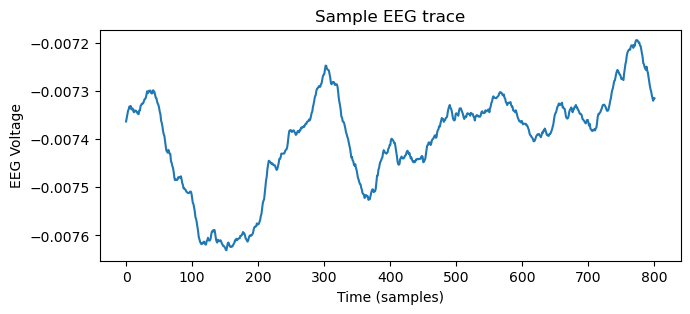

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

# Plot an example EEG trace
plt.figure(figsize=(7.5, 3)); ax=plt.subplot(111)
plt.plot(eeg[2, 2, :])
plt.ylabel('EEG Voltage'); plt.xlabel('Time (samples)')
plt.title('Sample EEG trace')

This is the fundamental unit of EEG data analyses -- the EEG timeseries! Whether from scalp or RAM/intracranial, our core interest is understanding the properties of these timeseries relative to interesting behavioral or cognitive events. Typically, we understand EEG signals with **spectral decomposition**, which will be covered later.

EEG timeseries data from different subjects and contacts and time points can have wildly different voltage offsets and voltage scaling.  We can address these variations by **z-scoring**, which adjusts a set of data to give it a mean of 0 and a standard deviation of 1, bringing everything to a common offset and scale.  The mathematical definition of a Z-score:
$$
Z = \frac{x-\mu}{\sigma}
$$
where x is the observed value, $\mu$ is the mean, and $\sigma$ is the standard deviation.

In [ ]:
filtered_df, filtered_raw_events, eeg_mne_filt, filtered_event_id, filtered_event_idx = filter_by_trial_types(
    "WORD",
    events_df=evs,
    raw=raw,
    epochs=eeg_container,
)
eeg = eeg_mne_filt.get_data()          # shape: (n_epochs, n_channels, n_times)
eeg = eeg[:, 0:1, :]                     # pick channel 0
print('ind.region_pair:', elec_df.iloc[0]['ind.region'])
print(eeg.shape)

# calculate mean (average over time and then event)
mu = np.mean(np.mean(eeg[:, 0, :], 1), 0)
# calculate standard deviation between events (first averaging over time)
std_ = np.std(np.mean(eeg[:, 0, :], 1), 0)

# z-score
zeeg = (eeg-mu)/std_
print(zeeg.shape)

# Plot the trace averaged across all events
plt.figure(figsize=(7.5, 3)); ax=plt.subplot(111)
plt.plot(np.mean(zeeg[:, 0, :], 0), linewidth=2,)
plt.vlines([0.1*samplingrate], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', color='k')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], linestyle='--', color='k')
plt.xlabel('Time (samples)'); plt.ylabel('Z-scored Voltage')

### Referencing

Electrical potentials inherently reflect some kind of differential. In the case of EEG data, the voltage fluctuations we measure really reflect a difference between an electrode of interest and a "reference" electrode placed elsewhere (such as the mastoid or an arbitrary location in the brain). As such, noise on the reference electrode -- and other sources -- can contaminate our measurement of true neural signal in the raw data. 

To solve this, it is common to "re-reference" EEG data to mitigate sources of noise. We could have a whole discussion about different ways to re-reference data, and the advantages/disadvantages of each, but there are two common ways of re-referencing I'll mention here. 

The most common re-reference used in this lab is the **bipolar** reference, in which the signal from each channel is subtracted from its neighbor. The result is an estimate of a cleaner signal that putatively reflects activity at the midpoint of the two physical recording contacts (we sometimes call this midpoint a **virtual electrode**). The bipolar reference has several advantages: (1) it's very simple to implement, (2) it typically does a good job at removing widespread noise, and (3) it ensures that your re-referenced traces reflect activity that is very close to the original electrodes. 

(One downside is that bipolar re-referencing can actually reduce your ability to detect true neural signals, or mislocalize its origin, especially if two adjancent electrodes were detecting a common source of electrical activity.)

### Optional

You may also encounter the **common average** reference, in which the average signal across all electrodes (or perhaps within a predefined anatomical region) is subtracted from each. This method is less likely to destroy local signals, and also does a good job removing widespread noise or reference noise, but can potentially contaminate originally-clean electrodes with unmitigated noise from a completely different part of the brain. 

Neither method is perfect, and there are more sophisiticated approaches out there. For the sake of this tutorial, we're going to focus on the bipolar reference. But it is often nice to try different referencing schemes in your analysis to ensure that your results don't change drastically from one to the other. 

<center>
<img src="http://www.bem.fi/book/13/fi/1303.gif">
</center>

Compare contact_1, contact_2, and the dash separated pairs in the label column.  The bipolar referencing scheme works by subtracting contact_1 from contact_2, and recording that signal in the EEG file.  The brain regions and coordinates identified in the various columns are typically taken from the location in between the two electrodes which make up the bipolar pair.

**Generate a time series plot for R1111M of a bipolar pair in the superior temporal gyrus for the first word recall event of the first session (Optional)**

### PTSA
PTSA (Penn Time Series Analysis) is a Python library built by the University of Pennsylvania’s Computational Memory Lab to handle large EEG datasets, especially for memory experiments. I

We can convert from MNE to PTSA using these functions here.

In [ ]:
# raw
evs = reader.load_events(event_type="ieeg")
raw = reader.load_raw(acquisition="monopolar")
raw_ptsa = mne_raw_to_ptsa(raw)
raw_ptsa

In [19]:
evs

,onset,duration,sample,trial_type,response_time,stim_file,item_name,serialpos,list,test,answer,experiment,session,subject
0,0.000,18.208,23207,SESS_START,NaN,NaN,NaN,-999,-999,"[0, 0, 0]",NaN,FR1,0,R1111M
1,18.208,10.000,32311,COUNTDOWN_START,NaN,NaN,NaN,-999,-999,"[0, 0, 0]",NaN,FR1,0,R1111M
2,28.636,3.709,37524,COUNTDOWN_END,NaN,NaN,NaN,-999,-999,"[0, 0, 0]",NaN,FR1,0,R1111M
3,32.345,1.600,39379,PRACTICE_WORD,NaN,NaN,WATCH,1,-1,"[0, 0, 0]",NaN,FR1,0,R1111M
4,34.745,1.600,40579,PRACTICE_WORD,NaN,NaN,RHINO,2,-1,"[0, 0, 0]",NaN,FR1,0,R1111M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
760,2823.996,15.269,1435126,REC_WORD,14.747,NaN,PEACH,-999,24,"[0, 0, 0]",NaN,FR1,0,R1111M
761,2839.265,282.462,1442760,REC_END,NaN,NaN,NaN,-999,24,"[0, 0, 0]",NaN,FR1,0,R1111M
762,3121.727,0.000,1583983,TRIAL,NaN,NaN,NaN,-999,25,"[0, 0, 0]",NaN,FR1,0,R1111M
763,3121.727,10.000,1583983,COUNTDOWN_START,NaN,NaN,NaN,-999,25,"[0, 0, 0]",NaN,FR1,0,R1111M


In [ ]:
# epochs
epochs_ptsa = mne_epochs_to_ptsa(eeg_container, evs)
epochs_ptsa

In [21]:
# We can select out word events and the first five channels using PTSA, just like the numpy array
epochs_ptsa_filt = epochs_ptsa[filtered_event_idx, mono_df.index[0:5]]

# Lets look at the resulting data
epochs_ptsa_filt

<xarray.TimeSeries (event: 288, channel: 5, time: 801)>
array([[[ 0.00359565,  0.00359486, ...,  0.00342192,  0.00342392],
        [-0.00353169, -0.00351694, ..., -0.00356396, -0.00356596],
        ...,
        [-0.0051889 , -0.00518173, ..., -0.00507096, -0.00508172],
        [ 0.00270469,  0.00271066, ...,  0.00258316,  0.00258714]],

       [[ 0.00359287,  0.00357772, ...,  0.00360482,  0.00360681],
        [-0.0035807 , -0.0035807 , ..., -0.00353766, -0.00353488],
        ...,
        [-0.00523871, -0.0052427 , ..., -0.00527497, -0.00527696],
        [ 0.00264093,  0.00263296, ...,  0.00258116,  0.00258037]],

       ...,

       [[ 0.00347691,  0.00347492, ...,  0.00356099,  0.00355461],
        [-0.00366597, -0.00367274, ..., -0.00349583, -0.00349583],
        ...,
        [-0.00507972, -0.00508172, ..., -0.00525664, -0.00527099],
        [ 0.00267161,  0.00266564, ...,  0.00263894,  0.00263974]],

       [[ 0.00349763,  0.00350281, ...,  0.00326573,  0.00325975],
        [-0.00363569, -0.00364366, ..., -0.00365362, -0.00366079],
        ...,
        [-0.00519488, -0.00519368, ..., -0.00539371, -0.00538495],
        [ 0.00265767,  0.00265089, ...,  0.00262778,  0.00262699]]])
Coordinates: (12/18)
  * event          (event) object MultiIndex
  * onset          (event) float64 0.0 18.21 28.64 ... 1.142e+03 1.143e+03
  * duration       (event) float64 18.21 10.0 3.709 1.6 ... 4.292 1.118 2.553
  * sample         (event) int64 23207 32311 37524 ... 591988 594134 594693
  * trial_type     (event) object 'SESS_START' 'COUNTDOWN_START' ... 'REC_WORD'
  * response_time  (event) float64 nan nan nan nan nan ... nan nan 4.292 5.41
    ...             ...
  * experiment     (event) object 'FR1' 'FR1' 'FR1' 'FR1' ... 'FR1' 'FR1' 'FR1'
  * session        (event) int64 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
  * subject        (event) object 'R1111M' 'R1111M' ... 'R1111M' 'R1111M'
  * channel        (channel) <U6 'LPOG1' 'LPOG2' 'LPOG3' 'LPOG4' 'LPOG5'
  * time           (time) float64 0.0 0.002 0.004 0.006 ... 1.596 1.598 1.6
    samplerate     float64 500.0

## Event Related Potentials (ERPs)

In cognitive electrophysiology, we are interested in the mapping between behavior and neuroscience.  Event related potentials give us a foundational method for investigating this mapping.  Specifically, an ERP shows us what the brain (EEG) looks like in correspondance to a specific behavioral event -- for example, the onset of a word presentation.  The key characteristic of an ERP is that we want to baseline correct using the voltage trace prior to the event of interest (i.e. subtract the average), such that we can see specifically what effect the behavioral event has on the neural signal.

To carry out an ERP analysis on the voltage data, we must 1. Load the desired events, 2. Filter to only encoding events, 3. Get the voltage for all encoding events, 4. Baseline correct, 5. Get a logical index of recall status, 6. Plot
the average subsequently recalled and subsequently forgotten voltage traces.

**Subsequent Memory Effect** 

The subsequent memory effect (SME) refers to systematic differences in neural activity during the encoding of information that predict whether that information will later be remembered or forgotten. In EEG and ERP studies, this is examined by time-locking brain activity to the encoding event and comparing trials that are subsequently recalled with those that are not. A reliable difference between these conditions indicates that the neural processes engaged at the time of encoding contribute to successful memory formation. SMEs are interpreted as neural markers of effective encoding and are commonly used to study the timing and mechanisms by which the brain supports memory.

In [ ]:
# First calculate recalled 
evs = reader.load_events(event_type="ieeg")
# 1. Keep only WORD and REC_WORD
evs_wr, _, _, _, _ = filter_by_trial_types(
    ["WORD", "REC_WORD"],
    events_df=evs,
)
# 2. Split into study and recall
recalled_df = evs_wr[evs_wr["trial_type"] == "WORD"].copy()
rec = evs_wr[evs_wr["trial_type"] == "REC_WORD"].copy()

# 3. Build recall sets per list
rec_sets = (
    rec.groupby("list")["item_name"]
    .apply(set)
    .to_dict()
)

# 4. Compute recalled flag for study trials
recalled_df["recalled"] = recalled_df.apply(
    lambda row: row["item_name"] in rec_sets.get(row["list"], set()),
    axis=1,
)

recalled_df.head()

In [23]:
# Load 1700ms long EEG events from 250ms before event to 1600ms after
trange = (-0.25, 1.6)
eeg_container = reader.load_epochs(tmin=trange[0], tmax=trange[1], acquisition="monopolar", preload=True)

Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Used Annotations descriptions: ['COUNTDOWN_END', 'COUNTDOWN_START', 'DISTRACT_END', 'DISTRACT_START', 'ORIENT', 'PRACTICE_DISTRACT_END', 'PRACTICE_DISTRACT_START', 'PRACTICE_REC_END', 'PRACTICE_REC_START', 'PRACTICE_WORD', 'PROB', 'REC_END', 'REC_START', 'REC_WORD', 'SESS_START', 'START', 'STOP', 'TRIAL', 'WORD']
Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting me

/home1/zrentala/bidsreader/bidsreader/bidsreader.py:321: RuntimeWarning: Omitted 1 annotation(s) that were outside data range.
  raw = read_raw_bids(bp)


1 bad epochs dropped


In [ ]:
import numpy as np

eeg = eeg_container.get_data()
sr = eeg_container.info['sfreq']
event_index = round(sr * (-trange[0]))  # trange is in seconds, so sr * seconds = samples
time_vals = (np.arange(eeg.shape[2])-event_index)*1000/sr

eeg = eeg[filtered_event_idx, 0:1]
print('ind.region:', combined_mono_df.iloc[0]['ind.region'])

# Get recalled/not recalled status
# Note, the values are 0 and 1 in the database.  It is essential to turn this into a boolean array
# so that numpy will later process it as a boolean mask, and not as indices of 0 and 1 to repeatedly
# index the eeg with.
rec_status = recalled_df['recalled']==True

index_200ms = round(sr*200/1000)
mu = np.mean(np.mean(eeg[:, 0, :index_200ms], 1), 0)
std_ = np.std(np.mean(eeg[:, 0, :index_200ms], 0), 0, ddof=1)

zeeg = (eeg-mu)/std_

# Plot the trace averaged across all events
plt.figure(figsize=(7.5, 3)); ax=plt.subplot(111)
plt.plot(time_vals, np.mean(zeeg[:, 0, :], 0), linewidth=2,)
plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', color='k')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], linestyle='--', color='k')
plt.xlabel('Time (ms)'); plt.ylabel('Baseline Z-scored Voltage')
#plt.xlim(*trange)

# Plot the trace for rec/nrec separately
plt.figure(figsize=(7.5, 3)); ax=plt.subplot(111)
plt.plot(time_vals, np.mean(zeeg[rec_status, 0, :], 0), linewidth=2, label='Rec')
plt.plot(time_vals, np.mean(zeeg[~rec_status, 0, :], 0), linewidth=2, label='NRec')
plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', color='k')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], linestyle='--', color='k')
plt.legend()
plt.xlabel('Time (ms)'); plt.ylabel('Baseline Z-scored Voltage')
#plt.xlim(*trange)